In [37]:
import numpy as np
import pandas as pd
df=pd.read_csv("Fraud Detection Dataset.csv")


BDA LAB MIDTERM 
Group No. 11
Project No. 1
Jeremiah Huang (FA24-BBD-075)
BBD-4C


In [38]:
print(df.shape)

(51000, 12)


In [39]:
print(df.columns)

Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Time_of_Transaction', 'Device_Used', 'Location',
       'Previous_Fraudulent_Transactions', 'Account_Age',
       'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent'],
      dtype='object')


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  object 
 11  Fraudulent                        51000 non-null  int64  
dtypes: f

In [41]:
print("Missing Values:\n",df.isnull().sum())

Missing Values:
 Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64


In [42]:
# df=df.dropna()

In [43]:
df['Transaction_Amount']=df.Transaction_Amount.fillna(df.Transaction_Amount.median())
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [44]:
print(df.isnull().sum())

Transaction_ID                         0
User_ID                                0
Transaction_Amount                     0
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64


In [45]:
df['Time_of_Transaction']=df.Time_of_Transaction.fillna(df.Time_of_Transaction.mode()[0])
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,18.0,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [46]:
df['Device_Used']=df.Device_Used.fillna(df.Device_Used.mode()[0])
df.head()


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,18.0,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [47]:
df['Location']=df.Location.fillna(df.Location.mode()[0])
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,18.0,Mobile,Boston,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [48]:
df['Payment_Method']=df.Payment_Method.fillna(df.Payment_Method.mode()[0])
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,18.0,Mobile,Boston,3,115,9,UPI,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [49]:
print(df.isnull().sum())

Transaction_ID                      0
User_ID                             0
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64


Z Score


In [50]:
# Transaction_Amount Column
df['amount_zscore']=(df['Transaction_Amount']-df['Transaction_Amount'].mean())/df['Transaction_Amount'].std()


In [51]:
df['outliers']=(df['amount_zscore']>3) | (df['amount_zscore']<-3)
print("Outliers detected:",df['outliers'].sum())

Outliers detected: 508


Grouping 

In [52]:
user_behavior = df.groupby('User_ID')['Transaction_Amount'].agg(
    ['mean', 'max', 'count', 'sum'])
user_behavior.rename(columns={
    'mean'  : 'Avg_Spend',
    'max'   : 'Max_Spend',
    'count' : 'Total_Transactions',
    'sum'   : 'Total_Spend'
})

print("\nUser Spending Behavior:")
print(user_behavior.head())


User Spending Behavior:
                mean      max  count       sum
User_ID                                       
1000     2232.880000  4394.37     11  24561.68
1001     1997.949091  4326.28     11  21977.44
1002     1969.753750  3617.10      8  15758.03
1003     1770.486364  3857.29     11  19475.35
1004     2926.672500  4998.45      8  23413.38


In [53]:
type_analysis = df.groupby('Transaction_Type')['Transaction_Amount'].agg(['mean', 'count'])
print("\nSpending by Transaction Type:")
print(type_analysis)


Spending by Transaction Type:
                         mean  count
Transaction_Type                    
ATM Withdrawal    2953.410007  10164
Bank Transfer     3008.500815  10276
Bill Payment      3014.972886  10340
Online Purchase   2964.877893  10094
POS Payment       2921.470548  10126


Feature Engineering


In [54]:
def transaction_time(hr):
    if hr<=6 or hr>=22:
        return 1
    else:
        return 0
df['is_night']=df.Time_of_Transaction.apply(transaction_time)
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent,amount_zscore,outliers,is_night
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0,-0.341579,False,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0,-0.288351,False,0
2,T3,1860,2395.02,ATM Withdrawal,18.0,Mobile,Boston,3,115,9,UPI,0,-0.117488,False,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0,-0.584049,False,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0,-0.301378,False,0


In [55]:
def prior_fraud(has_done):
    if has_done > 0:
        return 1
    else:
        return 0
df['has_prior_fraud']=df['Previous_Fraudulent_Transactions'].apply(prior_fraud)
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent,amount_zscore,outliers,is_night,has_prior_fraud
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0,-0.341579,False,0,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0,-0.288351,False,0,1
2,T3,1860,2395.02,ATM Withdrawal,18.0,Mobile,Boston,3,115,9,UPI,0,-0.117488,False,0,1
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0,-0.584049,False,0,1
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0,-0.301378,False,0,1


In [56]:
def alert(transactions):
    if transactions > 10:
        return 1
    else:
        return 0
df['high_activity']=df['Number_of_Transactions_Last_24H'].apply(alert)
df.head()


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent,amount_zscore,outliers,is_night,has_prior_fraud,high_activity
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0,-0.341579,False,0,0,1
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0,-0.288351,False,0,1,0
2,T3,1860,2395.02,ATM Withdrawal,18.0,Mobile,Boston,3,115,9,UPI,0,-0.117488,False,0,1,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0,-0.584049,False,0,1,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0,-0.301378,False,0,1,0


In [57]:
df['fraud_risk_score'] = (
    df['amount_zscore']   * 0.4 +
    df['is_night']        * 0.2 +
    df['has_prior_fraud'] * 0.3 +
    df['high_activity']   * 0.1
)
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent,amount_zscore,outliers,is_night,has_prior_fraud,high_activity,fraud_risk_score
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0,-0.341579,False,0,0,1,-0.036632
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0,-0.288351,False,0,1,0,0.184660
2,T3,1860,2395.02,ATM Withdrawal,18.0,Mobile,Boston,3,115,9,UPI,0,-0.117488,False,0,1,0,0.253005
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0,-0.584049,False,0,1,0,0.066380
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0,-0.301378,False,0,1,0,0.179449


In [58]:
min_score = df['fraud_risk_score'].min()
max_score = df['fraud_risk_score'].max()
df['fraud_risk_score'] = (df['fraud_risk_score'] - min_score) / (max_score - min_score)
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent,amount_zscore,outliers,is_night,has_prior_fraud,high_activity,fraud_risk_score
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0,-0.341579,False,0,0,1,0.043880
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0,-0.288351,False,0,1,0,0.091312
2,T3,1860,2395.02,ATM Withdrawal,18.0,Mobile,Boston,3,115,9,UPI,0,-0.117488,False,0,1,0,0.105961
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0,-0.584049,False,0,1,0,0.065960
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0,-0.301378,False,0,1,0,0.090195


In [59]:
def risk_label(score):
    if score >= 0.7:
        return 'High Risk'
    elif score >= 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'
df['risk_label'] = df['fraud_risk_score'].apply(risk_label)

In [60]:
print("\nRisk Label Distribution:")
print(df['risk_label'].value_counts())


Risk Label Distribution:
risk_label
Low Risk     50492
High Risk      508
Name: count, dtype: int64


In [61]:
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent,amount_zscore,outliers,is_night,has_prior_fraud,high_activity,fraud_risk_score,risk_label
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0,-0.341579,False,0,0,1,0.043880,Low Risk
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0,-0.288351,False,0,1,0,0.091312,Low Risk
2,T3,1860,2395.02,ATM Withdrawal,18.0,Mobile,Boston,3,115,9,UPI,0,-0.117488,False,0,1,0,0.105961,Low Risk
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0,-0.584049,False,0,1,0,0.065960,Low Risk
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0,-0.301378,False,0,1,0,0.090195,Low Risk


SUMMARY STATISTICS AND CORRELATION

In [62]:
print(df[['Transaction_Amount','amount_zscore','fraud_risk_score']].describe())

       Transaction_Amount  amount_zscore  fraud_risk_score
count        51000.000000   5.100000e+04      51000.000000
mean          2972.920030  -1.309628e-17          0.124470
std           4918.801144   1.000000e+00          0.092477
min              5.030000  -6.033767e-01          0.000000
25%           1333.787500  -3.332382e-01          0.088073
50%           2524.100000  -9.124582e-02          0.118759
75%           3724.987500   1.528965e-01          0.146540
max          49997.800000   9.560232e+00          1.000000


In [63]:
print("Correlation with fraudulent column")
print(df[['Transaction_Amount','amount_zscore','fraud_risk_score','is_night',
'has_prior_fraud','high_activity','Fraudulent']].corr())

Correlation with fraudulent column
                    Transaction_Amount  amount_zscore  fraud_risk_score  \
Transaction_Amount            1.000000       1.000000          0.928121   
amount_zscore                 1.000000       1.000000          0.928121   
fraud_risk_score              0.928121       0.928121          1.000000   
is_night                      0.006511       0.006511          0.228211   
has_prior_fraud              -0.000461      -0.000461          0.279340   
high_activity                -0.002944      -0.002944          0.104487   
Fraudulent                    0.005359       0.005359          0.006464   

                    is_night  has_prior_fraud  high_activity  Fraudulent  
Transaction_Amount  0.006511        -0.000461      -0.002944    0.005359  
amount_zscore       0.006511        -0.000461      -0.002944    0.005359  
fraud_risk_score    0.228211         0.279340       0.104487    0.006464  
is_night            1.000000        -0.000109       0.001541    

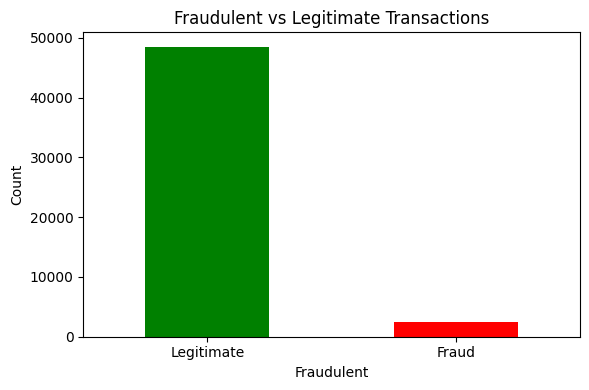

In [64]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
df['Fraudulent'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Fraudulent vs Legitimate Transactions')
plt.xticks([0, 1], ['Legitimate', 'Fraud'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()


<Axes: xlabel='risk_label'>

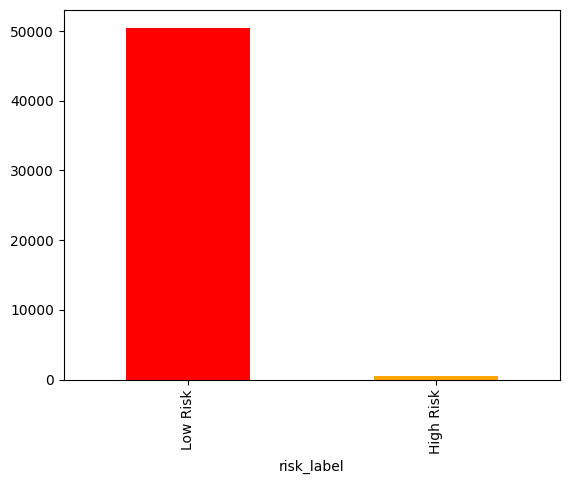

In [65]:
df['risk_label'].value_counts().plot(kind='bar', color=['red', 'orange', 'green'])


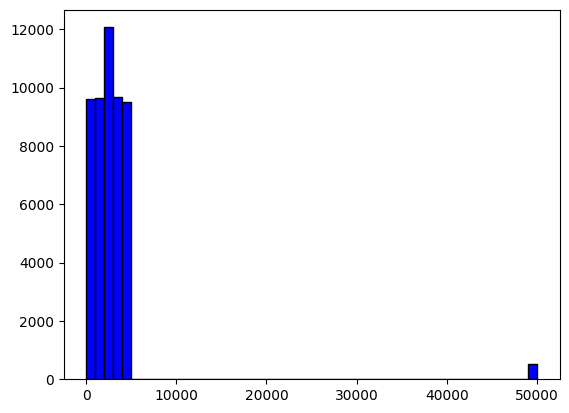

In [66]:
# df['risk_label'].value_counts().plot(kind='bar', color=['red', 'orange', 'green'])
plt.hist(df['Transaction_Amount'], bins=50, color='blue', edgecolor='black')
plt.show()